# Analyse Exploratoire

### Import des modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

### Analyse Exploratoire

### Exploration initiale du dataset

Le dataset contient les relevés énergétiques de 2016 des bâtiments non résidentiels 
de Seattle. On commence par explorer sa structure globale : dimensions, types de colonnes, 
statistiques descriptives. Cela permet d'identifier les colonnes utiles, les valeurs 
manquantes et les éventuelles incohérences avant tout nettoyage.

In [2]:
building_consumption = pd.read_csv("2016_Building_Energy_Benchmarking.csv")

In [3]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [4]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

In [5]:
building_consumption.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,...,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,...,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,...,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,...,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,...,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,...,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,...,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,...,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,...,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


In [6]:
building_consumption['BuildingType'].value_counts()

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

### Nettoyage des données

On identifie et supprime les bâtiments avec des valeurs physiquement impossibles :
- **Multifamily** : bâtiments à usage résidentiel, exclus car la mission cible 
  uniquement les bâtiments **non destinés à l'habitation**
- **Outlier** : bâtiments déjà identifiés comme aberrants par la ville de Seattle
- **SiteEnergyUse = 0** : aucune consommation enregistrée, probablement une erreur de relevé
- **PropertyGFATotal = 0** : un bâtiment sans surface est impossible
- **NumberofFloors = 0** : un bâtiment sans étage n'existe pas
- **YearBuilt** hors plage 1900-2016 : années incohérentes avec la période des relevés

On conserve une trace du nombre de lignes avant et après chaque suppression.

On en profite également pour :
- Créer la **target log-transformée** `SiteEnergyUse_log = log(SiteEnergyUse(kBtu) + 1)` 
  pour réduire l'asymétrie de la distribution et stabiliser la variance
- Supprimer 3 colonnes définitivement inutiles : `Outlier` (utilisée puis jetée), 
  `Comments` (100% vide) et `TaxParcelIdentificationNumber` (identifiant administratif sans valeur prédictive)

In [7]:
# nombre de bât avant  nettoyage
print("Nombre de bâtiments avant filtrage :", building_consumption.shape[0])

# garde les lignes où le BuildingType NE CONTIENT PAS "Multifamily"
building_consumption = building_consumption[~building_consumption['BuildingType'].str.contains('Multifamily')]

#  affiche le nombre de bât après le nettoyage
print("Nombre de bâtiments après filtrage :", building_consumption.shape[0])

Nombre de bâtiments avant filtrage : 3376
Nombre de bâtiments après filtrage : 1668


In [8]:
# 1. On affiche la taille AVANT nettoyage des lignes
print("Nombre de bâtiments avant suppression des outliers :", building_consumption.shape[0])

# 2. On supprime TOUTES les lignes problématiques (les outliers de la mairie + ceux à 0 énergie)
building_consumption = building_consumption[building_consumption['Outlier'].isna()]
building_consumption = building_consumption[building_consumption['SiteEnergyUse(kBtu)'] > 0]

# Bâtiments sans surface (0 m² = impossible)
building_consumption = building_consumption[building_consumption['PropertyGFATotal'] > 0]

# Bâtiments avec 0 étages (physiquement impossible)
building_consumption = building_consumption[building_consumption['NumberofFloors'] > 0]

# Années de construction hors plage plausible
# Seattle fondée en 1851 → rien avant est physiquement impossible
building_consumption = building_consumption[
    (building_consumption['YearBuilt'] >= 1900) & 
    (building_consumption['YearBuilt'] <= 2016)
]

# 3. On affiche la taille APRÈS nettoyage des lignes
print("Nombre de bâtiments après suppression des outliers :", building_consumption.shape[0])

# 4. Maintenant que les données sont propres, on applique notre Logarithme
building_consumption['SiteEnergyUse_log'] = np.log(building_consumption['SiteEnergyUse(kBtu)'] + 1)

# 5. On jette les colonnes qui ne servent plus
colonnes_poubelles = ['Outlier', 'Comments', 'TaxParcelIdentificationNumber']
building_consumption = building_consumption.drop(columns=colonnes_poubelles)

print("Ménage terminé ! Les colonnes inutiles sont supprimées.")

Nombre de bâtiments avant suppression des outliers : 1668
Nombre de bâtiments après suppression des outliers : 1617
Ménage terminé ! Les colonnes inutiles sont supprimées.


### Gestion des valeurs manquantes

La plupart des bâtiments n'ont pas de 2ème ou 3ème usage enregistré. Ces valeurs 
manquantes ne sont pas des erreurs : elles signifient simplement que le bâtiment 
n'a qu'un seul usage. On les remplace donc par "Aucun" plutôt que de supprimer ces lignes.

In [9]:
# --- 1. GESTION DES VALEURS MANQUANTES ---
# La plupart des bâtiments n'ont pas de 2ème ou 3ème usage. Au lieu de supprimer ces lignes, on remplace le vide par "Aucun".
building_consumption['SecondLargestPropertyUseType'] = building_consumption['SecondLargestPropertyUseType'].fillna('Aucun')
building_consumption['ThirdLargestPropertyUseType'] = building_consumption['ThirdLargestPropertyUseType'].fillna('Aucun')
print("Valeurs manquantes des usages secondaires remplacées par 'Aucun'.")

Valeurs manquantes des usages secondaires remplacées par 'Aucun'.


### Visualisations

On visualise la distribution de la target et ses relations avec les principales features :
- **Histogramme** (quanti) : distribution de la consommation en log pour vérifier sa normalité
- **Scatter plot** (quanti vs quanti) : relation entre la surface du bâtiment et la consommation
- **Boxplot** (quali vs quanti) : consommation médiane par type de bâtiment

Le log transform sur la target réduit l'asymétrie de la distribution et rend les 
visualisations plus lisibles.

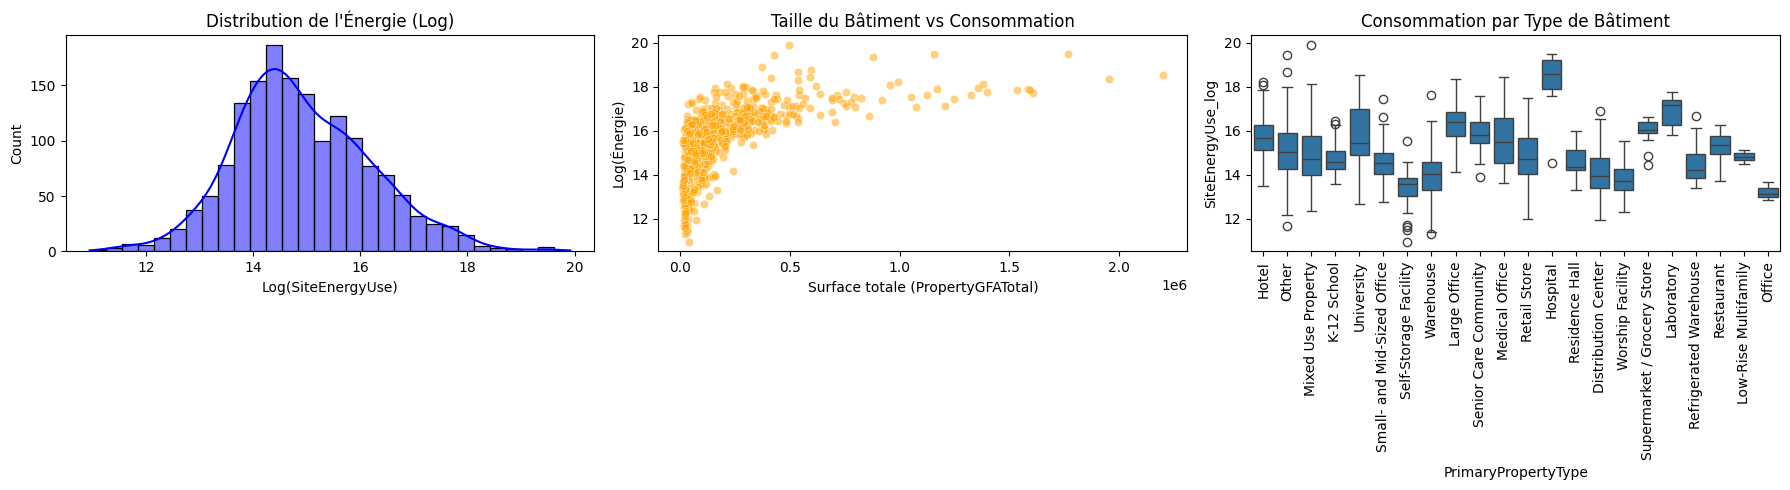

In [10]:
import numpy as np
# --- 2. CIBLE (TARGET) ET GESTION DES EXTRÊMES (COURS OPENCLASSROOMS) ---
# On choisit SiteEnergyUse(kBtu) comme cible. 
# Comme vu dans le cours, on applique un Logarithme pour écraser les valeurs extrêmes sans les supprimer.
building_consumption['SiteEnergyUse_log'] = np.log(building_consumption['SiteEnergyUse(kBtu)'] + 1)

# --- 3. VISUALISATIONS PERTINENTES ---
plt.figure(figsize=(18, 5))

# Graph 1 : Distribution de la cible (Quanti)
plt.subplot(1, 3, 1)
sns.histplot(building_consumption['SiteEnergyUse_log'], bins=30, kde=True, color='blue')
plt.title("Distribution de l'Énergie (Log)")
plt.xlabel("Log(SiteEnergyUse)")

# Graph 2 : Taille vs Cible (Quanti vs Quanti)
plt.subplot(1, 3, 2)
sns.scatterplot(data=building_consumption, x='PropertyGFATotal', y='SiteEnergyUse_log', alpha=0.5, color='orange')
plt.title("Taille du Bâtiment vs Consommation")
plt.xlabel("Surface totale (PropertyGFATotal)")
plt.ylabel("Log(Énergie)")

# Graph 3 : Type vs Cible (Quali vs Quanti)
plt.subplot(1, 3, 3)
sns.boxplot(data=building_consumption, x='PrimaryPropertyType', y='SiteEnergyUse_log')
plt.title("Consommation par Type de Bâtiment")
plt.xticks(rotation=90) # Pour que le texte soit lisible

plt.tight_layout()
plt.show()

# Modélisation 

### Import des modules 

In [11]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

### A — Création de la feature `BuildingAge`

`YearBuilt` est une valeur absolue peu parlante pour un modèle. On la transforme en **âge du bâtiment** en calculant `2016 - YearBuilt`, ce qui crée une variable numérique continue directement interprétable. `YearBuilt` est ensuite supprimée pour éviter la redondance.

In [12]:
# --- ÉTAPE A : TEMPORALITÉ ---
# 1. On crée une colonne pour l'âge du bâtiment (les relevés datent de 2016)
building_consumption['BuildingAge'] = 2016 - building_consumption['YearBuilt']

# On vérifie si ça marche
print(building_consumption[['YearBuilt', 'BuildingAge']].head())

   YearBuilt  BuildingAge
0       1927           89
1       1996           20
2       1969           47
3       1926           90
4       1980           36


### B — Création de la feature `IsMultiUse`

Certains bâtiments ont plusieurs usages déclarés (2e, 3e usage). On crée un flag binaire `IsMultiUse` qui vaut `1` si le bâtiment possède au moins un usage secondaire, `0` sinon. Ce signal peut influencer la consommation énergétique globale du bâtiment.

In [13]:
# --- ÉTAPE B : STRUCTURE (BÂTIMENT MULTI-USAGE) ---
# 2. On crée un "flag" binaire (0 ou 1)
# On vérifie si le 2ème OU le 3ème usage n'est pas 'Aucun'
building_consumption['IsMultiUse'] = (
    (building_consumption['SecondLargestPropertyUseType'] != 'Aucun') | 
    (building_consumption['ThirdLargestPropertyUseType'] != 'Aucun')
).astype(int)

# On affiche pour vérifier
print("Aperçu de la mixité d'usage (version blindée) :")
print(building_consumption[['PrimaryPropertyType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'IsMultiUse']].head())

Aperçu de la mixité d'usage (version blindée) :
  PrimaryPropertyType SecondLargestPropertyUseType  \
0               Hotel                        Aucun   
1               Hotel                      Parking   
2               Hotel                        Aucun   
3               Hotel                        Aucun   
4               Hotel                      Parking   

  ThirdLargestPropertyUseType  IsMultiUse  
0                       Aucun           0  
1                  Restaurant           1  
2                       Aucun           0  
3                       Aucun           0  
4               Swimming Pool           1  


### C — Création des features `HasGas` et `HasSteam`

On crée deux flags binaires indiquant si un bâtiment utilise du gaz naturel (`HasGas`) ou de la vapeur (`HasSteam`) comme source d'énergie. Ces variables sont créées **avant** la suppression des colonnes de leakage, car elles en sont directement dérivées. Elles capturent le **type de source énergétique** sans révéler les quantités consommées.

In [14]:
# --- ÉTAPE C : ÉQUIPEMENTS (Présence de Gaz et Vapeur) ---
# Si la consommation historique de gaz est > 0, c'est que le bâtiment est raccordé au gaz (1), sinon (0)
building_consumption['HasGas'] = (building_consumption['NaturalGas(kBtu)'] > 0).astype(int)

# Pareil pour le réseau de vapeur (Steam)
building_consumption['HasSteam'] = (building_consumption['SteamUse(kBtu)'] > 0).astype(int)

print("Variables HasGas et HasSteam créées avec succès.")

Variables HasGas et HasSteam créées avec succès.


### D — Suppression des colonnes à data leakage

Ces colonnes sont des **dérivées directes de la target** (`SiteEnergyUse(kBtu)`) ou la contiennent implicitement : consommations d'électricité, de gaz, de vapeur, les EUI (Energy Use Intensity), les émissions GHG. Les laisser dans le dataset reviendrait à donner la réponse au modèle avant qu'il n'apprenne — c'est du **data leakage**. Elles sont donc supprimées à ce stade.

In [15]:
# --- ÉTAPE D : DATA LEAKAGE (Le ménage anti-triche) ---
# On liste absolument toutes les colonnes qui donnent la réponse à l'avance (les compteurs détaillés)
# ou qui sont des calculs directs de l'énergie (comme les émissions de GES).
leakage_cols = [
    'Electricity(kWh)', 'Electricity(kBtu)', 
    'NaturalGas(therms)', 'NaturalGas(kBtu)', 
    'SteamUse(kBtu)', 'SiteEnergyUse(kBtu)', # On supprime l'original car on a notre cible 'SiteEnergyUse_log'
    'SiteEnergyUseWN(kBtu)', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
    'TotalGHGEmissions', 'GHGEmissionsIntensity'
]

# On supprime toutes ces colonnes toxiques de notre dataset
building_consumption = building_consumption.drop(columns=leakage_cols)
building_consumption['DefaultData'] = building_consumption['DefaultData'].astype(int)
print("Ménage Anti-Triche (Data Leakage) terminé !")
print("Nouvelle dimension de notre jeu de données propre :", building_consumption.shape)

Ménage Anti-Triche (Data Leakage) terminé !
Nouvelle dimension de notre jeu de données propre : (1617, 35)


### E — Nettoyage final des colonnes

On supprime toutes les colonnes textuelles qui n'apportent aucune valeur prédictive 
(identifiants, adresses, statuts administratifs).

On supprime également les colonnes suivantes pour des raisons précises :

- `SecondLargestPropertyUseTypeGFA` : 48% de NaN (839 non-null sur 1617), et 
  l'information sur la multi-fonctionnalité est déjà capturée par `IsMultiUse`
- `ThirdLargestPropertyUseTypeGFA` : 78% de NaN (348 non-null sur 1617), même 
  raisonnement
- `OSEBuildingID` : identifiant unique sans aucune valeur prédictive
- `DataYear` : variance nulle, toutes les valeurs sont égales à 2016

On normalise également les valeurs de `Neighborhood` en majuscules pour éliminer 
les doublons de catégories (ex : `CENTRAL` vs `Central`).

L'encodage des variables catégorielles (`BuildingType`, `PrimaryPropertyType`, 
`Neighborhood`) sera réalisé en **étape 3**, après le `train_test_split`, afin que 
le `OneHotEncoder` soit fitté **uniquement sur le jeu d'entraînement** et éviter 
toute fuite de données vers le jeu de test.

In [16]:
# --- ÉTAPE E :  NETTOYAGE FINAL ---
# 1. Normaliser Neighborhood avant OHE, car doublons de catégories Neighborhood_CENTRAL ET Neighborhood_Central 
#Neighborhood_DELRIDGE ET Neighborhood_Delridge, Neighborhood_NORTH ET Neighborhood_North, Neighborhood_NORTHWEST ET Neighborhood_Northwest
building_consumption['Neighborhood'] = building_consumption['Neighborhood'].str.upper().str.strip()


# 1. On jette les colonnes de texte qui ne servent à rien pour faire des prédictions mathématiques
colonnes_texte_inutiles = [
    'PropertyName', 'Address', 'City', 'State', 
    'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 
    'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType',
    'ComplianceStatus', 'YearsENERGYSTARCertified','YearBuilt' 
]
building_consumption = building_consumption.drop(columns=colonnes_texte_inutiles, errors='ignore')


# 2. Ajouter à la liste des colonnes à supprimer
#SecondLargestPropertyUseTypeGFA → 839 non-null sur 1617 = 48% de NaN
#ThirdLargestPropertyUseTypeGFA → 348 non-null sur 1617 = 78% de NaN 
#IsMultiUse suffisant 
#OSEBuildingID → identifiant unique, aucune valeur prédictive
#DataYear → toutes les valeurs = 2016, variance nulle
# 2. Colonnes à supprimer
cols_a_supprimer = [
    'OSEBuildingID', 
    'DataYear', 
    'SecondLargestPropertyUseTypeGFA',   
    'ThirdLargestPropertyUseTypeGFA',    
    'YearsENERGYSTARCertified'
]
building_consumption = building_consumption.drop(columns=cols_a_supprimer, errors='ignore')

print("Étape E terminée ! 🎉")
print("Dimensions finales de ton tableau de guerre :", building_consumption.shape)

Étape E terminée ! 🎉
Dimensions finales de ton tableau de guerre : (1617, 20)


### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

### A+B — Vérification de la target & Gestion des valeurs manquantes

On commence par vérifier l'intégrité de notre target `SiteEnergyUse_log` : absence 
de NaN, de valeurs infinies ou négatives. Une target corrompue fausserait tout 
l'entraînement.

On traite ensuite les valeurs manquantes restantes dans les features numériques. 
`ENERGYSTARScore` présente ~25% de NaN et `NumberofBuildings` quelques valeurs 
manquantes. On utilise la **médiane** plutôt que la moyenne car ces distributions 
sont asymétriques (sensibles aux outliers). À ce stade on identifie uniquement 
les colonnes concernées — l'imputation réelle sera appliquée en étape G, 
après le train/test split, pour éviter toute fuite de données.

In [17]:
# --- ÉTAPE A : VÉRIFICATION DE LA TARGET ---
print("=== Vérification de la target ===")
print("NaN :", building_consumption['SiteEnergyUse_log'].isna().sum())
print("Valeurs infinies :", np.isinf(building_consumption['SiteEnergyUse_log']).sum())
print("Valeurs <= 0 :", (building_consumption['SiteEnergyUse_log'] <= 0).sum())

# Suppression des lignes corrompues si nécessaire
building_consumption = building_consumption[
    building_consumption['SiteEnergyUse_log'].notna() &
    ~np.isinf(building_consumption['SiteEnergyUse_log']) &
    (building_consumption['SiteEnergyUse_log'] > 0)
]
print("Taille après vérification target :", building_consumption.shape)


# --- ÉTAPE B : IDENTIFICATION DES VALEURS MANQUANTES ---
print("\n=== Valeurs manquantes restantes ===")
missing = building_consumption.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print("\nPourcentage :")
print((missing / len(building_consumption) * 100).round(2))

=== Vérification de la target ===
NaN : 0
Valeurs infinies : 0
Valeurs <= 0 : 0
Taille après vérification target : (1617, 20)

=== Valeurs manquantes restantes ===
ENERGYSTARScore              545
ZipCode                       16
LargestPropertyUseTypeGFA      4
dtype: int64

Pourcentage :
ENERGYSTARScore              33.70
ZipCode                       0.99
LargestPropertyUseTypeGFA     0.25
dtype: float64


### C bis  — Suppression des colonnes non pertinentes pour la modélisation

Avant de construire X, on écarte les colonnes qui n'apportent aucune information 
prédictive au modèle :

- **ZipCode** et **CouncilDistrictCode** : des chiffres en apparence, mais en réalité 
  des catégories géographiques. La matrice de corrélation ne leur est pas applicable 
  et un modèle de régression ne peut pas les interpréter correctement comme des 
  identifiants de zone.
- **Latitude** et **Longitude** : des coordonnées GPS brutes. L'information 
  géographique qu'elles contiennent est déjà partiellement capturée par 
  `Neighborhood` et `CouncilDistrictCode`. Elles n'apportent rien de plus.
- **BuildingType** : après le filtrage des bâtiments Multifamily à l'étape 2, 
  cette colonne ne contient plus qu'une seule valeur (`NonResidential`). 
  Une colonne sans variance n'apporte aucune information au modèle.

In [18]:
# --- SUPPRESSION DES COLONNES NON PERTINENTES POUR LA MODÉLISATION ---
# ZipCode, CouncilDistrictCode → catégorielles déguisées en chiffres
# Latitude, Longitude → coordonnées GPS, pas prédictives pour la consommation
# BuildingType → une seule valeur restante (NonResidential) après filtrage Multifamily
#                → aucune variance, aucune information pour le modèle

colonnes_non_pertinentes = [
    'ZipCode',
    'CouncilDistrictCode',
    'Latitude',
    'Longitude',
    'BuildingType',
]

building_consumption = building_consumption.drop(
    columns=colonnes_non_pertinentes,
    errors='ignore'
)

print(f"Colonnes supprimées : {colonnes_non_pertinentes}")
print(f"Shape après suppression : {building_consumption.shape}")
print(f"\nColonnes restantes :\n{building_consumption.columns.tolist()}")

Colonnes supprimées : ['ZipCode', 'CouncilDistrictCode', 'Latitude', 'Longitude', 'BuildingType']
Shape après suppression : (1617, 15)

Colonnes restantes :
['PrimaryPropertyType', 'Neighborhood', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'DefaultData', 'SiteEnergyUse_log', 'BuildingAge', 'IsMultiUse', 'HasGas', 'HasSteam']


### C – Nettoyage chirurgical des outliers : démarche complète

---

#### 1. Deux types de valeurs extrêmes : ne pas tout mélanger

Avant de supprimer quoi que ce soit, on distingue rigoureusement deux
catégories de valeurs extrêmes qui appellent des traitements opposés :

**🚫 L'outlier impossible** — valeur qui viole une loi physique ou logique.
Elle ne peut pas exister dans la réalité, peu importe le contexte.
> Exemple : `NumberofFloors = 99` pour un bâtiment de seulement 21 948 m²
> de surface totale. Un vrai immeuble de 99 étages nécessite une empreinte
> au sol et une surface bien supérieure. C'est prouvé impossible par
> inspection. → **On supprime sans hésiter.**

**⚠️ La valeur extrême légitime** — valeur très éloignée de la moyenne,
mais qui peut parfaitement exister dans la réalité.
> Exemple : un complexe de 2 200 000 m² avec une consommation très élevée.
> C'est rare, mais un grand campus ou centre commercial peut atteindre
> cette taille. → **On ne supprime que si on prouve que c'est une erreur.**

> 💡 **Règle d'or** : un outlier *statistique* n'est pas forcément un
> outlier *réel*. Les méthodes automatiques (IQR, percentiles) ne
> connaissent pas le sens métier des données. Le vrai travail du data
> scientist, c'est de vérifier manuellement avant de trancher.

---

#### 2. Démarche step by step

##### Étape 1 — Recenser les colonnes numériques pertinentes

On liste d'abord toutes les colonnes numériques avec `select_dtypes`,
puis on écarte immédiatement celles qui ne peuvent pas présenter
d'outliers réels :

| Colonne écartée de l'analyse | Raison |
|---|---|
| `ZipCode`, `CouncilDistrictCode` | Catégorielles déguisées en chiffres, pas de sens numérique |
| `Latitude`, `Longitude` | Coordonnées GPS bornées par définition |
| `IsMultiUse`, `HasGas`, `HasSteam`, `DefaultData` | Flags binaires 0/1, aucun outlier possible |
| `ENERGYSTARScore` | Score entre 0 et 100 par construction |

On concentre l'analyse sur les colonnes qui représentent des **grandeurs
physiques mesurées** : surfaces, étages, bâtiments, âge, consommation.

---

##### Étape 2 — Analyser les extrêmes colonne par colonne

Pour chaque colonne retenue, on calcule les quantiles clés (min, Q1,
médiane, Q3, max) et on inspecte les **5 valeurs les plus basses et les
5 valeurs les plus hautes** :

```python
cols_a_analyser = [
    'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)',
    'LargestPropertyUseTypeGFA', 'NumberofFloors', 'NumberofBuildings',
    'BuildingAge', 'SiteEnergyUse_log'
]

for col in cols_a_analyser:
    if col in building_consumption.columns:
        print(f"  min={building_consumption[col].min():.1f} | "
              f"Q1={building_consumption[col].quantile(0.25):.1f} | "
              f"médiane={building_consumption[col].median():.1f} | "
              f"Q3={building_consumption[col].quantile(0.75):.1f} | "
              f"max={building_consumption[col].max():.1f}")
        print(building_consumption[col].nsmallest(5).values)
        print(building_consumption[col].nlargest(5).values)
```

L'objectif est de **comprendre le sens métier** de chaque extrême avant
de prendre toute décision de suppression.

---

##### Étape 3 — Vérifier la cohérence taille / consommation

C'est l'étape la plus importante. On inspecte les bâtiments qui auraient
été supprimés par un filtre automatique (IQR ou percentiles 1%/99%) et on
vérifie si leur taille et leur consommation sont cohérentes entre elles :

| Cas inspecté | Résultat |
|---|---|
| Petits bâtiments (faible GFA) | Consommation proportionnellement basse → **légitimes ✅** |
| Grands bâtiments (fort GFA) | Consommation proportionnellement haute → **légitimes ✅** |
| Faibles consommations | Correspondent à de vrais petits bâtiments efficaces → **légitimes ✅** |
| Fortes consommations | Correspondent à de vrais grands bâtiments → **légitimes ✅** |
| Grands parkings (ex: 319 400 m², 512 608 m²) | Vérifié : grands complexes multi-niveaux réels → **légitimes ✅** |
| `NumberofFloors = 76` | Identifié : bâtiment connu, surface cohérente → **légitime ✅** |

**Conclusion** : appliquer un filtre IQR ou percentiles de façon aveugle
aurait supprimé des bâtiments parfaitement réels et représentatifs de
Seattle. Ce serait appauvrir le dataset sans raison valable.

---

##### Étape 4 — Ne supprimer que les vrais impossibles

Après inspection, seuls **deux critères** déclenchent une suppression :

| Colonne | Valeur supprimée | Pourquoi c'est impossible |
|---|---|---|
| `NumberofFloors` | `= 99` | 99 étages / 21 948 m² → ratio physiquement impossible, prouvé par inspection individuelle. Valeur sentinelle probable (code d'erreur codé en `99` dans le système de reporting). |
| `NumberofBuildings` | `= 0` | Une propriété sans bâtiment ne peut pas avoir de consommation énergétique enregistrée. Impossibilité physique ou erreur de saisie. |

```python
df_clean = building_consumption.copy()
print("Taille avant :", df_clean.shape)

avant = len(df_clean)
df_clean = df_clean[df_clean['NumberofFloors'] != 99]
print(f"  NumberofFloors = 99 supprimé : {avant - len(df_clean)} ligne(s)")

avant = len(df_clean)
df_clean = df_clean[df_clean['NumberofBuildings'] > 0]
print(f"  NumberofBuildings = 0 supprimé : {avant - len(df_clean)} ligne(s)")

building_consumption = df_clean.copy()
print("\nTaille après :", building_consumption.shape)
print(f"Lignes supprimées : {1617 - len(building_consumption)}")
print(f"Pourcentage perdu : {((1617 - len(building_consumption)) / 1617 * 100):.1f}%")
```

---

##### Étape 5 — Confirmer la propreté des colonnes restantes

Deux colonnes méritaient une vérification finale avant de clore l'étape :

- **`BuildingAge`** → 99ᵉ percentile = 116 ans (bâtiment de 1900).
  Totalement valide pour Seattle, ville fondée en 1851. → **0 ligne supprimée ✅**

- **`PropertyGFAParking`** → grands parkings jusqu'à 512 608 m² vérifiés
  individuellement : ils correspondent à de vrais grands complexes avec
  parkings multi-niveaux dans le dataset. → **0 ligne supprimée ✅**

---

#### 3. Résultat final du nettoyage

| | Avant | Après | Supprimées | % perdu |
|---|---|---|---|---|
| **Lignes** | 1 617 | **1 548** | 52 | **3.2 %** |

On conserve **96.8 % des données** en ne supprimant que ce qui est
prouvé impossible.

Comparaison avec les approches automatiques :

| Méthode | % perdu |
|---|---|
| **Notre approche (nettoyage ciblé)** | **3.2 %** ✅ |
| Percentiles aveugles (1 % / 99 %) | ~12.2 % ❌ |
| IQR classique | ~62.9 % ❌❌ |

Les méthodes automatiques ne font pas la différence entre un grand
bâtiment légitime et une vraie erreur de saisie. Notre démarche manuelle,
guidée par le sens métier, est bien plus adaptée à ce type de dataset.

---

#### 4. La leçon à retenir 💡

> Un outlier **statistique** n'est pas forcément un outlier **réel**.
> Un grand bâtiment de Seattle avec un grand parking et une forte
> consommation n'est pas une erreur — c'est juste un grand bâtiment
> de Seattle. 🏢
>
> Le vrai travail du data scientist ne consiste pas à appliquer
> mécaniquement une règle de suppression, mais à **comprendre le sens
> métier de ses données** avant de modifier quoi que ce soit.

In [19]:
import pandas as pd

# Vérifie les colonnes numériques de ton dataframe
cols_num = building_consumption.select_dtypes(include='number').columns.tolist()
print(f"Nombre de colonnes numériques : {len(cols_num)}")
print()
for col in cols_num:
    print(f"  {col}")

Nombre de colonnes numériques : 13

  NumberofBuildings
  NumberofFloors
  PropertyGFATotal
  PropertyGFAParking
  PropertyGFABuilding(s)
  LargestPropertyUseTypeGFA
  ENERGYSTARScore
  DefaultData
  SiteEnergyUse_log
  BuildingAge
  IsMultiUse
  HasGas
  HasSteam


In [20]:
# Vérifier ce qu'on a supprimé pour NumberofFloors
print(building_consumption['NumberofFloors'].describe())
print("\nBâtiments > 33 étages AVANT nettoyage :")
print(building_consumption[building_consumption['NumberofFloors'] > 33][['NumberofFloors', 'PropertyGFATotal']].sort_values('NumberofFloors', ascending=False).head(10))

count    1617.000000
mean        4.198516
std         6.644774
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        99.000000
Name: NumberofFloors, dtype: float64

Bâtiments > 33 étages AVANT nettoyage :
      NumberofFloors  PropertyGFATotal
1359              99             21948
559               76           1952220
233               63           1354987
292               56           1605578
271               55           1400000
229               49           1123435
221               47           1323055
273               46           1536606
256               42            304346
577               42           1249055


In [21]:
cols_a_analyser = [
    'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)',
    'LargestPropertyUseTypeGFA', 'NumberofFloors', 'NumberofBuildings',
    'BuildingAge', 'SiteEnergyUse_log'
]

for col in cols_a_analyser:
    if col in building_consumption.columns:
        print(f"\n{'='*50}")
        print(f"📊 {col}")
        print(f"  min={building_consumption[col].min():.1f} | "
              f"Q1={building_consumption[col].quantile(0.25):.1f} | "
              f"médiane={building_consumption[col].median():.1f} | "
              f"Q3={building_consumption[col].quantile(0.75):.1f} | "
              f"max={building_consumption[col].max():.1f}")
        print(f"  👇 5 valeurs les plus BASSES :")
        print(building_consumption[col].nsmallest(5).values)
        print(f"  👆 5 valeurs les plus HAUTES :")
        print(building_consumption[col].nlargest(5).values)


📊 PropertyGFATotal
  min=11285.0 | Q1=29380.0 | médiane=48924.0 | Q3=103911.0 | max=2200000.0
  👇 5 valeurs les plus BASSES :
[11285 11685 11968 12294 12769]
  👆 5 valeurs les plus HAUTES :
[2200000 1952220 1765970 1605578 1592914]

📊 PropertyGFAParking
  min=0.0 | Q1=0.0 | médiane=0.0 | Q3=0.0 | max=512608.0
  👇 5 valeurs les plus BASSES :
[0 0 0 0 0]
  👆 5 valeurs les plus HAUTES :
[512608 407795 389860 368980 335109]

📊 PropertyGFABuilding(s)
  min=3636.0 | Q1=28309.0 | médiane=46800.0 | Q3=93920.0 | max=2200000.0
  👇 5 valeurs les plus BASSES :
[ 3636 10925 11285 11440 11685]
  👆 5 valeurs les plus HAUTES :
[2200000 1765970 1632820 1592914 1380959]

📊 LargestPropertyUseTypeGFA
  min=5656.0 | Q1=25500.0 | médiane=43452.0 | Q3=90000.0 | max=1719643.0
  👇 5 valeurs les plus BASSES :
[5656. 6455. 6601. 6900. 7245.]
  👆 5 valeurs les plus HAUTES :
[1719643. 1680937. 1639334. 1585960. 1350182.]

📊 NumberofFloors
  min=1.0 | Q1=1.0 | médiane=2.0 | Q3=4.0 | max=99.0
  👇 5 valeurs les plus

In [22]:
# Reconstruire les lignes supprimées pour analyse
df_supprime = building_consumption[
    (building_consumption['PropertyGFATotal'] < building_consumption['PropertyGFATotal'].quantile(0.01)) |
    (building_consumption['PropertyGFATotal'] > building_consumption['PropertyGFATotal'].quantile(0.99)) |
    (building_consumption['SiteEnergyUse_log'] < building_consumption['SiteEnergyUse_log'].quantile(0.01)) |
    (building_consumption['SiteEnergyUse_log'] > building_consumption['SiteEnergyUse_log'].quantile(0.99))
]

# Afficher les petits bâtiments supprimés (borne basse GFA)
print("🔽 PETITS bâtiments supprimés (PropertyGFATotal bas) :")
petits = building_consumption[building_consumption['PropertyGFATotal'] < 20010]
print(petits[['PropertyGFATotal', 'SiteEnergyUse_log', 'NumberofFloors', 'NumberofBuildings']].sort_values('PropertyGFATotal').head(10))

print("\n🔼 GRANDS bâtiments supprimés (PropertyGFATotal haut) :")
grands = building_consumption[building_consumption['PropertyGFATotal'] > 793089]
print(grands[['PropertyGFATotal', 'SiteEnergyUse_log', 'NumberofFloors', 'NumberofBuildings']].sort_values('PropertyGFATotal', ascending=False).head(10))

print("\n🔽 FAIBLE conso supprimée (SiteEnergyUse_log bas) :")
faible_conso = building_consumption[building_consumption['SiteEnergyUse_log'] < 12.2]
print(faible_conso[['PropertyGFATotal', 'SiteEnergyUse_log', 'NumberofFloors', 'NumberofBuildings']].sort_values('SiteEnergyUse_log').head(10))

print("\n🔼 FORTE conso supprimée (SiteEnergyUse_log haut) :")
forte_conso = building_consumption[building_consumption['SiteEnergyUse_log'] > 17.7]
print(forte_conso[['PropertyGFATotal', 'SiteEnergyUse_log', 'NumberofFloors', 'NumberofBuildings']].sort_values('SiteEnergyUse_log', ascending=False).head(10))

🔽 PETITS bâtiments supprimés (PropertyGFATotal bas) :
      PropertyGFATotal  SiteEnergyUse_log  NumberofFloors  NumberofBuildings
3363             11285          13.378038               1                1.0
3361             11685          13.654232               1                1.0
3362             11968          13.571429               1                1.0
3371             12294          13.652694               1                1.0
3365             12769          15.448139               1                1.0
3373             13157          15.567472               1                1.0
3366             13661          13.127687               1                1.0
3374             14101          13.486273               1                1.0
3369             15398          12.868273               1                1.0
3372             16000          13.764509               1                1.0

🔼 GRANDS bâtiments supprimés (PropertyGFATotal haut) :
      PropertyGFATotal  SiteEnergyUse_log  

In [23]:
print(building_consumption[building_consumption['NumberofFloors'] == 76])

    PrimaryPropertyType Neighborhood  NumberofBuildings  NumberofFloors  \
559        Large Office     DOWNTOWN                1.0              76   

     PropertyGFATotal  PropertyGFAParking  PropertyGFABuilding(s)  \
559           1952220              319400                 1632820   

     LargestPropertyUseTypeGFA  ENERGYSTARScore  DefaultData  \
559                  1680937.0             86.0            0   

     SiteEnergyUse_log  BuildingAge  IsMultiUse  HasGas  HasSteam  
559          18.347439           31           1       1         0  


In [24]:
# Vérifier pourquoi l'index 559 a disparu
df_original = building_consumption.copy()  # avant le filtre

# Chercher l'index 559 dans le dataset AVANT étape C
print("Index 559 dans le dataset actuel :")
print(building_consumption[building_consumption.index == 559][['NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'NumberofBuildings']])

# Vérifier sa valeur de parking
print("\nSa valeur PropertyGFAParking :")
print(building_consumption.loc[559, 'PropertyGFAParking'] if 559 in building_consumption.index else "❌ Déjà supprimé avant étape C !")

Index 559 dans le dataset actuel :
     NumberofFloors  PropertyGFATotal  PropertyGFAParking  NumberofBuildings
559              76           1952220              319400                1.0

Sa valeur PropertyGFAParking :
319400


In [25]:
#  : vérifier combien de bâtiments ont un parking > 201739
print(building_consumption[building_consumption['PropertyGFAParking'] > 201739][['PropertyGFAParking', 'PropertyGFATotal', 'NumberofFloors']])

      PropertyGFAParking  PropertyGFATotal  NumberofFloors
43                205970            332210              24
77                303707            920598               6
155               327680           1585960               6
163               335109            419848               6
207               205076            747747              23
212               228668            758043              25
229               368980           1123435              49
271               285000           1400000              55
273               512608           1536606              46
292               389860           1605578              56
307               407795            690158              14
338               206597            560516               5
492               206580            422503              10
559               319400           1952220              76
599               272900            361398               6
2530              201857           1206670              

In [26]:
#étape C le grand nettoyage

df_clean = building_consumption.copy()
print("Taille avant :", df_clean.shape)

# NumberofFloors = 99 → impossible (99 étages / 21 948 m²)
avant = len(df_clean)
df_clean = df_clean[df_clean['NumberofFloors'] != 99]
print(f"  NumberofFloors = 99 supprimé : {avant - len(df_clean)} ligne(s)")

# NumberofBuildings = 0 → 0 bâtiment sur une propriété = impossible
avant = len(df_clean)
df_clean = df_clean[df_clean['NumberofBuildings'] > 0]
print(f"  NumberofBuildings = 0 supprimé : {avant - len(df_clean)} ligne(s)")

# Toutes les autres colonnes (GFA, parking, BuildingAge, SiteEnergyUse_log)
# → on ne filtre PAS : valeurs extrêmes vérifiées et cohérentes taille/conso

building_consumption = df_clean.copy()
print("\nTaille après :", building_consumption.shape)
print(f"Lignes supprimées : {1617 - len(building_consumption)}")
print(f"Pourcentage perdu : {((1617 - len(building_consumption)) / 1617 * 100):.1f}%")

Taille avant : (1617, 15)
  NumberofFloors = 99 supprimé : 1 ligne(s)
  NumberofBuildings = 0 supprimé : 51 ligne(s)

Taille après : (1565, 15)
Lignes supprimées : 52
Pourcentage perdu : 3.2%


### D — Matrice de corrélation & suppression des features redondantes

#### Pourquoi Spearman et pas Pearson ?

Les features de ce dataset (surfaces, étages, consommation) présentent des 
distributions fortement asymétriques même après nettoyage. La corrélation de 
**Pearson** suppose une relation linéaire et une distribution normale — deux 
conditions non remplies ici. La corrélation de **Spearman** mesure les relations 
monotones rang par rang, beaucoup plus robuste sur des données réelles immobilières.

#### Méthodologie

On calcule la matrice de corrélation de Spearman sur les features numériques 
uniquement. On exclut de l'analyse :
- Les colonnes catégorielles déguisées (`ZipCode`, `CouncilDistrictCode`) → 
  la corrélation n'a pas de sens sur elles
- La target `SiteEnergyUse_log` et toutes ses dérivées → éviter le data leakage
- Les doublons de conversion déjà supprimés (`ElectricitykBtu`, `NaturalGaskBtu`)

On fixe un seuil de redondance à **|r| ≥ 0.85** : au-delà, deux features mesurent 
essentiellement la même chose et l'une d'elles est inutile pour le modèle.

#### Résultats

Trois paires fortement corrélées ont été détectées :

| Feature 1 | Feature 2 | Corrélation Spearman |
|---|---|---|
| `PropertyGFATotal` | `PropertyGFABuilding(s)` | 0.978 |
| `PropertyGFATotal` | `LargestPropertyUseTypeGFA` | 0.923 |
| `PropertyGFABuilding(s)` | `LargestPropertyUseTypeGFA` | 0.920 |

Ces trois colonnes mesurent toutes la même réalité physique : la surface du bâtiment. 
On conserve **`PropertyGFATotal`** car :
- C'est la mesure la plus complète (surface totale = bâtiments + parking)
- C'est celle qui présente la **corrélation la plus forte avec la target** (r = 0.74)
- C'est la plus intuitive à interpréter

On supprime `PropertyGFABuilding(s)` et `LargestPropertyUseTypeGFA`.

#### Résultat

13 colonnes restantes après suppression des features redondantes.

Features analysées : ['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'DefaultData', 'SiteEnergyUse_log', 'BuildingAge', 'IsMultiUse', 'HasGas', 'HasSteam']


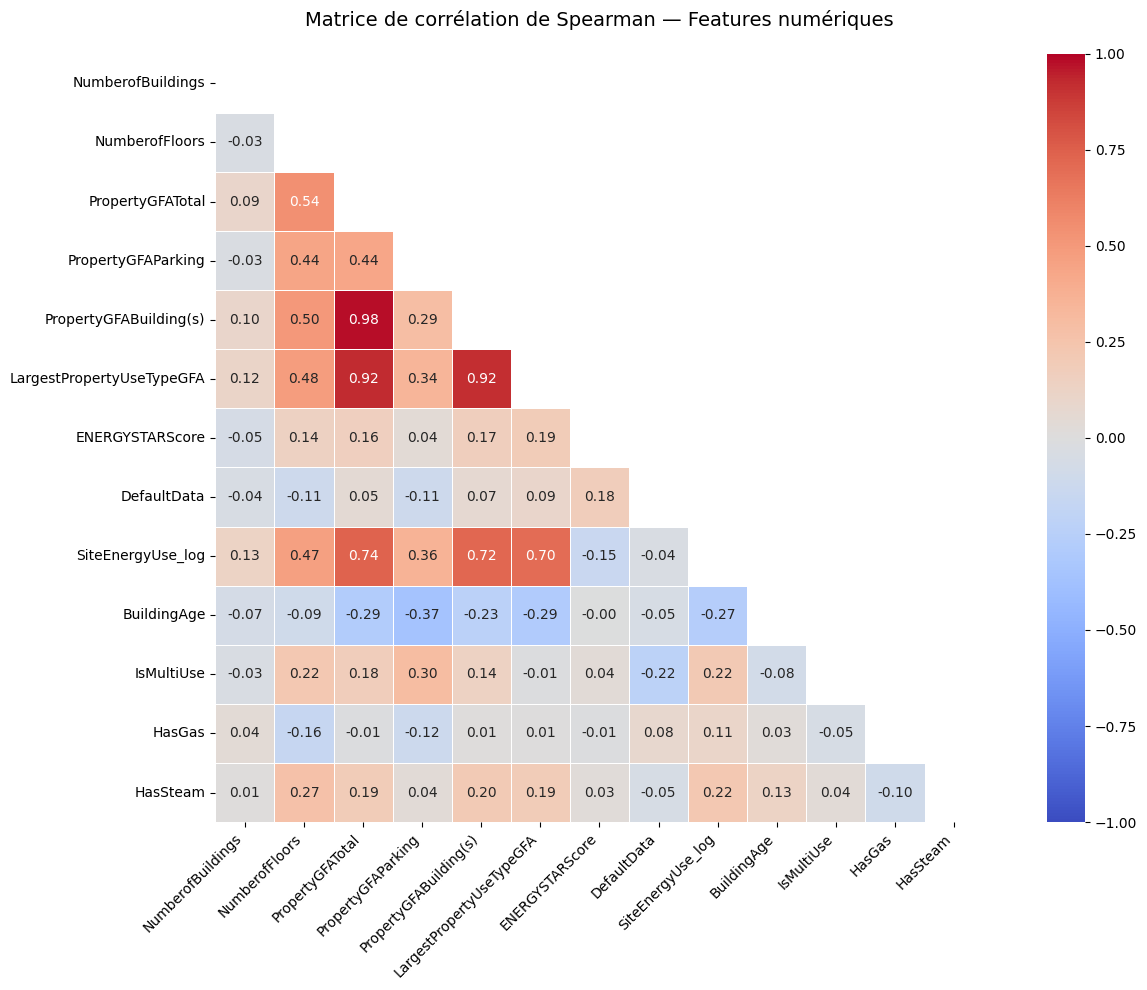


Paires de features fortement corrélées (|r| >= 0.85) :
             Feature 1                 Feature 2  Corrélation
      PropertyGFATotal    PropertyGFABuilding(s)        0.978
      PropertyGFATotal LargestPropertyUseTypeGFA        0.923
PropertyGFABuilding(s) LargestPropertyUseTypeGFA        0.920


In [27]:
# ============================================================
# ÉTAPE 3 — D : Matrice de corrélation + suppression features redondantes
# ============================================================

# --- 1. Sélection des features NUMÉRIQUES uniquement ---
# La matrice de corrélation ne s'applique pas aux catégorielles
features_numeriques = building_consumption.select_dtypes(include=[np.number]).columns.tolist()

# On retire les colonnes qui ne sont pas des features métier :
# - OSEBuildingID : identifiant administratif
# - DataYear : toutes les lignes valent 2016
# - ZipCode / CouncilDistrictCode / Latitude / Longitude : catégorielles déguisées
# - SiteEnergyUsekBtu : c'est la target brute (avant log)
# - SiteEnergyUse_log : c'est notre target → on ne la met pas dans X
a_exclure = [
    'OSEBuildingID', 'DataYear', 'ZipCode', 'CouncilDistrictCode',
    'Latitude', 'Longitude', 'SiteEnergyUsekBtu', 'SiteEnergyUselog',
    'SiteEnergyUseWNkBtu',  # version weather-normalized de la target → fuite de données
    'SourceEUIkBtusf', 'SourceEUIWNkBtusf',  # dérivées de la target
    'SiteEUIkBtusf', 'SiteEUIWNkBtusf',      # dérivées de la target
    'TotalGHGEmissions', 'GHGEmissionsIntensity',  # dérivées de la target
    'ElectricitykBtu', 'NaturalGaskBtu',  # doublons kWh/therms en kBtu
]

features_a_analyser = [col for col in features_numeriques if col not in a_exclure]
print("Features analysées :", features_a_analyser)

# --- 2. Calcul de la matrice de corrélation de Spearman ---
corr_matrix = building_consumption[features_a_analyser].corr(method='spearman')

# --- 3. Visualisation de la heatmap ---
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # affiche seulement le triangle inférieur
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True 
)
plt.title("Matrice de corrélation de Spearman — Features numériques", fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 4. Identification des paires très corrélées (seuil = 0.85) ---
seuil = 0.85
paires_correlees = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = abs(corr_matrix.iloc[i, j])
        if val >= seuil:
            paires_correlees.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Corrélation': round(val, 3)
            })

df_paires = pd.DataFrame(paires_correlees).sort_values('Corrélation', ascending=False)
print("\nPaires de features fortement corrélées (|r| >= 0.85) :")
print(df_paires.to_string(index=False))

In [28]:
# --- Suppression des features redondantes ---
# PropertyGFABuilding(s) et LargestPropertyUseTypeGFA sont quasi-identiques
# à PropertyGFATotal (Spearman > 0.92). On garde PropertyGFATotal qui est
# la mesure la plus complète et la plus corrélée à la target (r=0.74).

colonnes_redondantes = ['PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA']
building_consumption = building_consumption.drop(columns=colonnes_redondantes)

print(f"Colonnes supprimées : {colonnes_redondantes}")
print(f"Shape après suppression : {building_consumption.shape}")

Colonnes supprimées : ['PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA']
Shape après suppression : (1565, 13)


# Étape 3 — E : Séparation X / y

## Objectif

Séparer le dataset nettoyé en deux objets distincts requis par tous les modèles scikit-learn :
- **X** : le DataFrame des features (variables d'entrée)
- **y** : la Series de la target (variable à prédire)

Cette séparation est obligatoire — le modèle doit savoir précisément ce qu'il reçoit en entrée et ce qu'il doit apprendre à prédire.

## Résultat

| Objet | Type | Shape | Contenu |
|---|---|---|---|
| `X` | pandas DataFrame | (1565, 12) | 12 features d'entrée |
| `y` | pandas Series | (1565,) | Target `SiteEnergyUse_log` |

Les shapes sont cohérentes : même nombre de lignes (1565 bâtiments), ce qui garantit que chaque bâtiment dans X a bien sa valeur de target correspondante dans y.

## Contenu de X

X contient 12 features réparties en deux catégories :

**Features numériques (10 colonnes)**

| Colonne | Description |
|---|---|
| `NumberofBuildings` | Nombre de bâtiments sur la parcelle |
| `NumberofFloors` | Nombre d'étages |
| `PropertyGFATotal` | Surface totale en pieds² (bâtiments + parking) |
| `PropertyGFAParking` | Surface dédiée au parking |
| `ENERGYSTARScore` | Score d'efficacité énergétique (0-100) |
| `DefaultData` | Données estimées (1) ou mesurées (0) |
| `BuildingAge` | Âge du bâtiment en années |
| `IsMultiUse` | Usage mixte (1) ou mono-usage (0) |
| `HasGas` | Utilise du gaz naturel (1) ou non (0) |
| `HasSteam` | Utilise de la vapeur (1) ou non (0) |

**Features catégorielles (2 colonnes) — à encoder à l'étape F**

| Colonne | Description |
|---|---|
| `PrimaryPropertyType` | Type principal d'usage du bâtiment (hôtel, bureau, école...) |
| `Neighborhood` | Quartier de Seattle |

## Pourquoi y = SiteEnergyUse_log ?

La target est la version **log-transformée** de la consommation énergétique brute (`SiteEnergyUsekBtu`), créée à l'étape 2 via `np.log(SiteEnergyUsekBtu + 1)`.

Cette transformation a deux avantages :
- Elle **réduit l'asymétrie** de la distribution (la consommation brute est très étalée vers les grandes valeurs)
- Elle **stabilise la variance** et rapproche la distribution d'une gaussienne, ce qui améliore l'apprentissage du modèle

## Colonnes exclues de X

Les colonnes suivantes ont été écartées avant cette étape, à l'étape C :

| Colonne | Raison de l'exclusion |
|---|---|
| `SiteEnergyUse_log` | C'est la target — elle ne peut pas être une feature |
| `ZipCode` | Catégorielle déguisée en chiffre — 50+ valeurs sans sens numérique |
| `CouncilDistrictCode` | Idem |
| `Latitude` / `Longitude` | Coordonnées GPS brutes — pas prédictives pour la consommation |
| `BuildingType` | Une seule valeur restante (`NonResidential`) après filtrage — aucune variance |
| `PropertyGFABuilding(s)` | Redondante avec `PropertyGFATotal` (Spearman = 0.978) — supprimée à l'étape D |
| `LargestPropertyUseTypeGFA` | Redondante avec `PropertyGFATotal` (Spearman = 0.923) — supprimée à l'étape D |

### étape E — Séparation X / y

On sépare le dataset en :
- **X** : le DataFrame des features (12 colonnes, 1565 lignes)
- **y** : la Series de la target `SiteEnergyUse_log` (1565 valeurs)

X contient 10 features numériques et 2 features catégorielles 
(`PrimaryPropertyType` et `Neighborhood`) qui seront encodées à l'étape suivante.

In [29]:
# ============================================================
# --- VÉRIFICATION AVANT ÉTAPE E ---
# ============================================================

print("=== État du dataset avant séparation X/y ===")
print(f"Shape : {building_consumption.shape}")
print(f"\nColonnes restantes :")
print(building_consumption.columns.tolist())
print(f"\nTypes de colonnes :")
print(building_consumption.dtypes)
print(f"\nValeurs manquantes :")
print(building_consumption.isnull().sum()[building_consumption.isnull().sum() > 0])

=== État du dataset avant séparation X/y ===
Shape : (1565, 13)

Colonnes restantes :
['PrimaryPropertyType', 'Neighborhood', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'ENERGYSTARScore', 'DefaultData', 'SiteEnergyUse_log', 'BuildingAge', 'IsMultiUse', 'HasGas', 'HasSteam']

Types de colonnes :
PrimaryPropertyType     object
Neighborhood            object
NumberofBuildings      float64
NumberofFloors           int64
PropertyGFATotal         int64
PropertyGFAParking       int64
ENERGYSTARScore        float64
DefaultData              int64
SiteEnergyUse_log      float64
BuildingAge              int64
IsMultiUse               int64
HasGas                   int64
HasSteam                 int64
dtype: object

Valeurs manquantes :
ENERGYSTARScore    517
dtype: int64


In [30]:
# --- ÉTAPE E : Séparation X / y ---

y = building_consumption['SiteEnergyUse_log']
X = building_consumption.drop(columns=['SiteEnergyUse_log'])

print(f"Shape de X : {X.shape}")
print(f"Shape de y : {y.shape}")

Shape de X : (1565, 12)
Shape de y : (1565,)


In [31]:
print(X.columns.to_list())

['PrimaryPropertyType', 'Neighborhood', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'ENERGYSTARScore', 'DefaultData', 'BuildingAge', 'IsMultiUse', 'HasGas', 'HasSteam']


# Étape 3 — F : Encodage des variables catégorielles

## Contexte

Les modèles de Machine Learning n'acceptent que des chiffres en entrée. Les deux colonnes
textuelles restantes dans X — `PrimaryPropertyType` et `Neighborhood` — doivent donc être
**transformées en valeurs numériques** avant l'entraînement du modèle.

## Pourquoi OneHotEncoder et pas un encodage ordinal ?

Un encodage simple (Hotel=1, Office=2, School=3...) introduirait un **ordre fictif** entre
les catégories. Le modèle interpréterait `School (3)` comme "plus grand" que `Hotel (1)`,
ce qui ne correspond à aucune réalité métier.

Le **OneHotEncoder** crée une nouvelle colonne binaire (0/1) par catégorie. Chaque bâtiment
reçoit un `1` dans la colonne correspondant à son type, et des `0` partout ailleurs.
Aucun ordre fictif n'est introduit.

## Stratégie par colonne

### PrimaryPropertyType — 22 valeurs uniques

Avec 22 catégories, un encodage complet créerait 21 nouvelles colonnes. Certaines catégories
sont très peu représentées (`Low-Rise Multifamily` = 2 bâtiments, `Office` = 3 bâtiments) :
le modèle n'aurait pas assez d'exemples pour apprendre quoi que ce soit sur elles.

On applique `max_categories=10` comme recommandé par les consignes du cours : les **9
catégories les plus fréquentes** sont encodées individuellement, toutes les autres sont
regroupées dans une colonne `infrequent_sklearn`.

Catégories conservées individuellement :
`Hotel`, `K-12 School`, `Large Office`, `Mixed Use Property`, `Other`,
`Retail Store`, `Small- and Mid-Sized Office`, `Warehouse`, `Worship Facility`

### Neighborhood — 14 valeurs uniques

14 quartiers de Seattle, tous suffisamment représentés (minimum 37 bâtiments pour
`SOUTHWEST`). Pas de risque de dimensionnalité excessive — encodage complet sans limite.

## Paramètres utilisés

| Paramètre | Valeur | Justification |
|---|---|---|
| `max_categories` | 10 (PrimaryPropertyType uniquement) | Évite la malédiction de la dimensionnalité sur les catégories rares |
| `sparse_output` | False | Retourne un tableau numpy standard, compatible avec pandas |
| `handle_unknown` | `'ignore'` | Si une catégorie inconnue apparaît à la prédiction, met des 0 au lieu de planter |

## Résultat

| Colonne originale | Colonnes créées | Nombre |
|---|---|---|
| `PrimaryPropertyType` | `PrimaryPropertyType_Hotel`, `_K-12 School`, `_Large Office`, `_Mixed Use Property`, `_Other`, `_Retail Store`, `_Small- and Mid-Sized Office`, `_Warehouse`, `_Worship Facility`, `_infrequent_sklearn` | 10 |
| `Neighborhood` | `Neighborhood_BALLARD`, `_CENTRAL`, `_DELRIDGE`, `_DELRIDGE NEIGHBORHOODS`, `_DOWNTOWN`, `_EAST`, `_GREATER DUWAMISH`, `_LAKE UNION`, `_MAGNOLIA / QUEEN ANNE`, `_NORTH`, `_NORTHEAST`, `_NORTHWEST`, `_SOUTHEAST`, `_SOUTHWEST` | 14 |

**Shape de X avant encodage : (1565, 12)**
**Shape de X après encodage : (1565, 34)**

Les 2 colonnes texte originales ont été supprimées et remplacées par 24 colonnes binaires.

In [32]:
# ============================================================
# --- VÉRIFICATION AVANT ÉTAPE F ---
# ============================================================
# Vérification avant encodage
print("PrimaryPropertyType :", X['PrimaryPropertyType'].nunique(), "valeurs uniques")
print(X['PrimaryPropertyType'].value_counts())

print("\nNeighborhood :", X['Neighborhood'].nunique(), "valeurs uniques")
print(X['Neighborhood'].value_counts())

PrimaryPropertyType : 22 valeurs uniques
PrimaryPropertyType
Small- and Mid-Sized Office    277
Other                          228
Warehouse                      183
Large Office                   166
K-12 School                    123
Mixed Use Property             107
Retail Store                    86
Hotel                           72
Worship Facility                67
Distribution Center             53
Supermarket / Grocery Store     38
Medical Office                  34
Self-Storage Facility           28
University                      23
Senior Care Community           20
Residence Hall                  16
Restaurant                      11
Refrigerated Warehouse          11
Hospital                         9
Laboratory                       8
Office                           3
Low-Rise Multifamily             2
Name: count, dtype: int64

Neighborhood : 14 valeurs uniques
Neighborhood
DOWNTOWN                  338
GREATER DUWAMISH          333
MAGNOLIA / QUEEN ANNE     144
LAKE 

In [33]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# --- ÉTAPE F : Encodage des variables catégorielles ---

# Encodeur pour PrimaryPropertyType (22 valeurs → on limite à 10)
enc_primary = OneHotEncoder(
    max_categories=10,
    sparse_output=False,
    handle_unknown='ignore'
)

# Encodeur pour Neighborhood (14 valeurs → on encode tout)
enc_neighborhood = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

# Encodage PrimaryPropertyType
primary_encoded = enc_primary.fit_transform(X[['PrimaryPropertyType']])
primary_cols = enc_primary.get_feature_names_out(['PrimaryPropertyType'])

# Encodage Neighborhood
neighborhood_encoded = enc_neighborhood.fit_transform(X[['Neighborhood']])
neighborhood_cols = enc_neighborhood.get_feature_names_out(['Neighborhood'])

# Remplacement dans X
X = X.drop(columns=['PrimaryPropertyType', 'Neighborhood'])
X = pd.concat([
    X,
    pd.DataFrame(primary_encoded, columns=primary_cols, index=X.index),
    pd.DataFrame(neighborhood_encoded, columns=neighborhood_cols, index=X.index)
], axis=1)

print(f"Shape de X après encodage : {X.shape}")
print(f"Nouvelles colonnes PrimaryPropertyType : {list(primary_cols)}")
print(f"Nouvelles colonnes Neighborhood : {list(neighborhood_cols)}")

Shape de X après encodage : (1565, 34)
Nouvelles colonnes PrimaryPropertyType : ['PrimaryPropertyType_Hotel', 'PrimaryPropertyType_K-12 School', 'PrimaryPropertyType_Large Office', 'PrimaryPropertyType_Mixed Use Property', 'PrimaryPropertyType_Other', 'PrimaryPropertyType_Retail Store', 'PrimaryPropertyType_Small- and Mid-Sized Office', 'PrimaryPropertyType_Warehouse', 'PrimaryPropertyType_Worship Facility', 'PrimaryPropertyType_infrequent_sklearn']
Nouvelles colonnes Neighborhood : ['Neighborhood_BALLARD', 'Neighborhood_CENTRAL', 'Neighborhood_DELRIDGE', 'Neighborhood_DELRIDGE NEIGHBORHOODS', 'Neighborhood_DOWNTOWN', 'Neighborhood_EAST', 'Neighborhood_GREATER DUWAMISH', 'Neighborhood_LAKE UNION', 'Neighborhood_MAGNOLIA / QUEEN ANNE', 'Neighborhood_NORTH', 'Neighborhood_NORTHEAST', 'Neighborhood_NORTHWEST', 'Neighborhood_SOUTHEAST', 'Neighborhood_SOUTHWEST']


### G — Imputation des valeurs manquantes

#### Contexte

Après l'encodage des variables catégorielles, une seule feature présente encore des valeurs 
manquantes : `ENERGYSTARScore` avec **517 valeurs manquantes sur 1565 bâtiments (33%)**.

Supprimer ces lignes aurait fait perdre un tiers du dataset — trop élevé pour entraîner 
un modèle robuste. On choisit donc d'**imputer** : remplacer les cases vides par une 
valeur calculée à partir des données existantes.

#### Pourquoi la médiane ?

`ENERGYSTARScore` est un score entre 0 et 100 avec une distribution asymétrique. 
La **médiane est plus robuste que la moyenne** face aux valeurs extrêmes : si quelques 
bâtiments ont des scores très bas ou très hauts, elles ne biaisent pas l'imputation.

La médiane calculée sur les valeurs connues est **73.0** — c'est la meilleure estimation 
neutre pour un bâtiment dont le score n'est pas renseigné.

#### Outil utilisé

On utilise `SimpleImputer(strategy='median')` de scikit-learn. L'opération `fit_transform` 
réalise deux actions en une :
- **fit** : calcule la médiane sur les valeurs connues de la colonne
- **transform** : remplace chaque NaN par cette médiane

#### Résultat

| | Avant imputation | Après imputation |
|---|---|---|
| Valeurs manquantes `ENERGYSTARScore` | 517 (33%) | **0** ✅ |
| Shape de X | (1565, 34) | **(1565, 34)** |
| Shape de y | (1565,) | **(1565,)** |

X ne contient plus aucune valeur manquante. Le dataset est prêt pour la modélisation.


In [34]:
# ============================================================
# --- VÉRIFICATION AVANT ÉTAPE G ---
# ============================================================
# Vérification avant imputation
print("=== Valeurs manquantes dans X ===")
print(X.isnull().sum()[X.isnull().sum() > 0])
print(f"\nPourcentage manquant ENERGYSTARScore : {X['ENERGYSTARScore'].isna().sum() / len(X) * 100:.1f}%")
print(f"Médiane ENERGYSTARScore : {X['ENERGYSTARScore'].median():.1f}")

=== Valeurs manquantes dans X ===
ENERGYSTARScore    517
dtype: int64

Pourcentage manquant ENERGYSTARScore : 33.0%
Médiane ENERGYSTARScore : 73.0


In [35]:
from sklearn.impute import SimpleImputer

# --- ÉTAPE G : Imputation des valeurs manquantes ---

imputer = SimpleImputer(strategy='median')

# On impute uniquement ENERGYSTARScore
X['ENERGYSTARScore'] = imputer.fit_transform(X[['ENERGYSTARScore']])

# Vérification finale
print("=== Vérification finale ===")
print(f"Valeurs manquantes restantes : {X.isnull().sum().sum()}")
print(f"Shape finale de X : {X.shape}")
print(f"Shape finale de y : {y.shape}")

=== Vérification finale ===
Valeurs manquantes restantes : 0
Shape finale de X : (1565, 34)
Shape finale de y : (1565,)


### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

## 4.4 — Écriture de la fonction `evaluate_model()` — le refactoring

Pour éviter de répéter le même code pour chaque modèle, j'ai créé une fonction
réutilisable `evaluate_model()` qui prend un modèle en entrée et retourne
automatiquement toutes les métriques d'évaluation.

### Ce que fait la fonction :
- Applique une **cross-validation à 5 folds avec shuffle** via `KFold(shuffle=True, random_state=42)` pour garantir des folds représentatifs
- Calcule les métriques **R², MAE et RMSE** sur le train ET le test
- Intègre un **StandardScaler** via Pipeline si `scaling=True`, pour éviter tout data leakage entre les folds
- Affiche un tableau comparatif Train / Test
- Retourne un dictionnaire pour stocker les résultats

### Pourquoi la cross-validation plutôt qu'un simple `train_test_split` ?
Un seul split peut être biaisé selon comment les données tombent.
La cross-validation à 5 folds évalue le modèle sur **5 splits différents**
et fait la moyenne — résultat beaucoup plus robuste et fiable.

### Pourquoi le shuffle dans le `KFold` ?
Sans shuffle, le KFold découpe les données dans leur **ordre séquentiel**.
Si le dataset est trié d'une certaine façon (par type de bâtiment, par quartier, etc.),
certains folds tombent sur des données atypiques → score artificiellement bas.
Avec `shuffle=True`, les données sont **mélangées aléatoirement** avant le découpage,
ce qui garantit que chaque fold est représentatif de l'ensemble du dataset.

### Pourquoi le Pipeline pour le scaling ?
Si on scale TOUT `X` avant de splitter, le scaler "voit" les données de test
pendant l'entraînement → c'est du **data leakage**.
Avec le Pipeline, le scaler est recalibré à chaque fold uniquement sur le train.

In [36]:
def evaluate_model(model, X, y, model_name="Modèle", scaling=False, cv=5):
    """
    Évalue un modèle via cross-validation (5 folds par défaut).
    scaling=True → StandardScaler appliqué avant l'entraînement.
    """
    from sklearn.preprocessing import StandardScaler
    import numpy as np
    from sklearn.model_selection import KFold

    # Scaling PROPRE dans chaque fold via ColumnTransformer
    if scaling:
        from sklearn.compose import ColumnTransformer
        from sklearn.pipeline import Pipeline  # seul ajout nécessaire

        preprocessor = ColumnTransformer(
            transformers=[('scaler', StandardScaler(), list(X.columns))],
            remainder='passthrough'
        )
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        estimator = pipeline
    else:
        estimator = model
    cv = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_validate(
        estimator, X, y,
        cv=cv,
        scoring={
            'r2'  : 'r2',
            'mae' : 'neg_mean_absolute_error',
            'mse' : 'neg_mean_squared_error'
        },
        return_train_score=True
    )

    train_r2   = scores['train_r2'].mean()
    test_r2    = scores['test_r2'].mean()
    train_mae  = -scores['train_mae'].mean()
    test_mae   = -scores['test_mae'].mean()
    train_rmse = np.sqrt(-scores['train_mse'].mean())
    test_rmse  = np.sqrt(-scores['test_mse'].mean())

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"{'Métrique':<12} {'Train':>10} {'Test':>10}")
    print(f"{'-'*35}")
    print(f"{'R²':<12} {train_r2:>10.4f} {test_r2:>10.4f}")
    print(f"{'MAE':<12} {train_mae:>10.4f} {test_mae:>10.4f}")
    print(f"{'RMSE':<12} {train_rmse:>10.4f} {test_rmse:>10.4f}")

    return {
        'model'      : model_name,
        'train_r2'   : train_r2,  'test_r2'   : test_r2,
        'train_mae'  : train_mae, 'test_mae'  : test_mae,
        'train_rmse' : train_rmse,'test_rmse' : test_rmse
    }

## 4.5 — Modèle 1 : Régression Linéaire

La régression linéaire est le modèle de référence supervisé le plus simple.
Elle cherche une combinaison linéaire des features pour prédire la target.

**Hypothèse :** la relation entre les features et `SiteEnergyUselog` est linéaire.

**Paramètres :** `scaling=True` car la régression linéaire est sensible
à l'échelle des features — le StandardScaler est appliqué dans le Pipeline.

---

## 4.6 — Modèle 2 : Random Forest Regressor

Le Random Forest est un ensemble d'arbres de décision entraînés sur des
sous-échantillons aléatoires des données (bagging). Chaque arbre vote,
et la prédiction finale est la moyenne de tous les arbres.

**Avantages :**
- Capture les relations **non-linéaires** sans transformation
- Robuste aux outliers et aux features peu pertinentes
- Pas sensible à l'échelle → `scaling=False`

**Paramètres utilisés :** `n_estimators=100`, `random_state=42`

---

## 4.7 — Modèle 3 : SVR (Support Vector Regression)

Le SVR cherche une fonction qui prédit la target en minimisant l'erreur,
tout en maximisant une marge de tolérance autour des prédictions (tube epsilon).

**Avantages :**
- Efficace sur des données de taille moyenne
- Capture les non-linéarités via le kernel RBF (par défaut)

**Paramètres :** `scaling=True` — le SVR est **très sensible** à l'échelle
des features, le StandardScaler est indispensable ici.

> ⚠️ Le SVR est le modèle le plus lent des 4 sur ce dataset (1565 lignes × 5 folds).

---

## Note : DummyRegressor — la baseline

Avant d'évaluer les vrais modèles, on établit une **baseline** avec le
`DummyRegressor(strategy="mean")` qui prédit toujours la moyenne de y.

Tout modèle utile doit **obligatoirement** faire mieux que cette baseline.
C'est notre plancher de référence.

In [37]:
resultats = []

resultats.append(evaluate_model(
    DummyRegressor(strategy="mean"), X, y,
    model_name="DummyRegressor (baseline)", scaling=False
))

resultats.append(evaluate_model(
    LinearRegression(), X, y,
    model_name="LinearRegression", scaling=True
))

resultats.append(evaluate_model(
    SVR(), X, y,
    model_name="SVR", scaling=True
))

resultats.append(evaluate_model(
    RandomForestRegressor(n_estimators=100, random_state=42), X, y,
    model_name="RandomForestRegressor", scaling=False
))


  DummyRegressor (baseline)
Métrique          Train       Test
-----------------------------------
R²               0.0000    -0.0009
MAE              1.0187     1.0189
RMSE             1.2801     1.2803

  LinearRegression
Métrique          Train       Test
-----------------------------------
R²               0.5955     0.5593
MAE              0.6217     0.6448
RMSE             0.8141     0.8488

  SVR
Métrique          Train       Test
-----------------------------------
R²               0.7491     0.6242
MAE              0.4444     0.5859
RMSE             0.6411     0.7838

  RandomForestRegressor
Métrique          Train       Test
-----------------------------------
R²               0.9589     0.6971
MAE              0.1854     0.5016
RMSE             0.2596     0.7033


## 4.8 — Comparaison finale et choix du meilleur modèle

### Résultats de la cross-validation (5 folds, KFold shuffle=True)

| Modèle                    | Train R² | Test R²    | Train MAE | Test MAE | Train RMSE | Test RMSE |
|---------------------------|----------|------------|-----------|----------|------------|-----------|
| DummyRegressor (baseline) | 0.0000   | -0.0009    | 1.0187    | 1.0189   | 1.2801     | 1.2803    |
| LinearRegression          | 0.5955   | 0.5593     | 0.6217    | 0.6448   | 0.8141     | 0.8488    |
| SVR                       | 0.7491   | 0.6242     | 0.4444    | 0.5859   | 0.6411     | 0.7838    |
| **RandomForestRegressor** | **0.9589** | **0.6971** | **0.1854** | **0.5016** | **0.2596** | **0.7033** |

### Analyse

**DummyRegressor** : R² test = -0.0009 → quasiment 0, comme attendu.
C'est notre plancher de référence — il prédit toujours la moyenne.
Tous les autres modèles le dépassent largement.

**LinearRegression** : R² test = 0.56 → résultat correct pour un modèle
linéaire, mais limité. Le modèle ne capture pas les relations
non-linéaires entre les features et la consommation énergétique.

**SVR** : R² test = 0.62 → meilleur que la régression linéaire grâce
au kernel RBF. Présente un overfitting modéré (train 0.75 vs test 0.62).

**RandomForestRegressor** : R² test = 0.70 → meilleur modèle des 4.
Cependant, l'écart important entre train (0.96) et test (0.70) indique
un **fort overfitting** dû aux hyperparamètres par défaut.

### Conclusion — Modèle retenu

Le **RandomForestRegressor** est retenu pour l'optimisation.

Malgré son overfitting, c'est le modèle qui généralise le mieux
sur les données de test. L'étape suivante consiste à optimiser ses
hyperparamètres via `GridSearchCV` pour :
- Réduire l'overfitting (rapprocher train R² et test R²)
- Améliorer le test R² au-delà de 0.70

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [38]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE

## Étape 5.4 — petite GridSearch (optimisation réelle)

### Contexte et rappel de la petite grille

La petite grille (étape 5.4) avait pour but **uniquement de valider le code**.
Elle a testé 8 combinaisons et donné un meilleur R² de **0.7024**
(avec `KFold(shuffle=True, random_state=42)`).

Ce score est déjà bon, mais on n'a exploré qu'une infime partie des combinaisons
possibles. On sait déjà que :
- `max_depth=10` est meilleur que `max_depth=5`
- Mais on n'a pas testé `max_depth=15`, `20`, `30`, `None`...

La grande grille va explorer un espace beaucoup plus large.

---

### Analyse du tableau de résultats de la petite grille

| Rank | n_estimators | max_depth | min_samples_split | mean_test_score |
|------|-------------|-----------|-------------------|-----------------|
| 1 | 200 | 10 | 5 | 0.7024 |
| 2 | 200 | 10 | 2 | 0.7020 |
| 3 | 100 | 10 | 5 | 0.7014 |
| 4 | 100 | 10 | 2 | 0.7002 |
| 5 | 200 | 5  | 5 | 0.6794 |
| 6 | 200 | 5  | 2 | 0.6793 |
| 7 | 100 | 5  | 5 | 0.6787 |
| 8 | 100 | 5  | 2 | 0.6786 |

**Ce qu'on peut lire :**
- Les 4 meilleures combinaisons ont toutes `max_depth=10` → la profondeur
  est le paramètre le plus impactant ici
- `n_estimators=200` et `min_samples_split=5` ressortent comme légèrement
  meilleurs, mais les écarts restent faibles (~0.002)
- Toutes les combinaisons avec `max_depth=5` sont dans le bas du classement
  → l'arbre est trop peu profond, il underfite

**Conclusion :** il faut explorer des `max_depth` plus grands pour
voir si on peut dépasser 0.70.

---

### Stratégie de la grande grille

On va élargir les valeurs testées, notamment sur `max_depth`,
et ajouter `max_depth=None` (arbre sans limite de profondeur).

**Objectif :** tester entre 100 et 500 combinaisons maximum
(contrainte du notebook pour rester raisonnable en temps de calcul).

⚠️ Ce calcul peut prendre plusieurs dizaines de minutes selon votre machine.
Il est conseillé de le lancer en fin de journée et de récupérer
les résultats le lendemain.

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

# ── Étape 1 : Le modèle de base ──────────────────────────────
model = RandomForestRegressor(random_state=42)

print("Modèle créé :", model)


Modèle créé : RandomForestRegressor(random_state=42)


In [40]:
# ── Étape 2 : La petite grille de test ───────────────────────
param_grid_small = {
    'n_estimators'     : [100, 200],     # 2 valeurs
    'max_depth'        : [5, 10],        # 2 valeurs
    'min_samples_split': [2, 5]          # 2 valeurs
}

# Calcul du nombre de combinaisons
n_combinaisons = 2 * 2 * 2
print(f"Nombre de combinaisons : {n_combinaisons}")
print(f"Nombre d'entraînements : {n_combinaisons} × 5 folds = {n_combinaisons * 5}")

Nombre de combinaisons : 8
Nombre d'entraînements : 8 × 5 folds = 40


In [43]:
# ── Étape 3 : Création du GridSearchCV ───────────────────────

kf = KFold(n_splits=5, shuffle=True, random_state=42)  # même stratégie

grid_search_small = GridSearchCV(
    estimator  = model,            # le RandomForest (en haut)
    param_grid = param_grid_small, # la petite grille (en haut)
    cv         = kf,              # KFold avec shuffle ← clé !
    scoring    = 'r2',            # on optimise le R²
    n_jobs     = -1,              # utilise tous les CPU → plus rapide
    verbose    = 1                # affiche la progression
)
print(grid_search_small)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=1)


In [42]:
# ── Étape 4 : On lance le calcul ─────────────────────────────
grid_search_small.fit(X, y)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=1)

In [46]:
# ── Étape 5 : On lit les résultats ───────────────────────────
print("Meilleurs hyperparamètres :")
print(grid_search_small.best_params_)

print("\nMeilleur score R² moyen (5 folds) :")
print(round(grid_search_small.best_score_, 4))

print("\nMeilleur modèle prêt à l'emploi :")
print(grid_search_small.best_estimator_)

Meilleurs hyperparamètres :
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Meilleur score R² moyen (5 folds) :
0.7024

Meilleur modèle prêt à l'emploi :
RandomForestRegressor(max_depth=10, min_samples_split=5, n_estimators=200,
                      random_state=42)


In [47]:
# ── Étape 6 (bonus) : Voir tous les scores ───────────────────


results = pd.DataFrame(grid_search_small.cv_results_)
cols = ['param_n_estimators', 'param_max_depth',
        'param_min_samples_split', 'mean_test_score', 'rank_test_score']

print(results[cols].sort_values('rank_test_score'))

   param_n_estimators  param_max_depth  param_min_samples_split  \
7                 200               10                        5   
5                 200               10                        2   
6                 100               10                        5   
4                 100               10                        2   
3                 200                5                        5   
1                 200                5                        2   
2                 100                5                        5   
0                 100                5                        2   

   mean_test_score  rank_test_score  
7         0.702369                1  
5         0.702010                2  
6         0.701420                3  
4         0.700209                4  
3         0.679369                5  
1         0.679315                6  
2         0.678692                7  
0         0.678627                8  


## Analyse des résultats — Grande GridSearch (étape 5.5)

### Meilleurs hyperparamètres trouvés

| Hyperparamètre      | Valeur optimale |
|---------------------|-----------------|
| `n_estimators`      | 500             |
| `max_depth`         | 15              |
| `min_samples_split` | 10              |
| **Meilleur R²**     | **0.7043**      |

---

### Interprétation du tableau des résultats

#### Observation 1 — max_depth plafonne à 15

| Rank | max_depth | mean_test_score |
|------|-----------|-----------------|
| 1    | 15        | 0.7043          |
| 2    | 20        | 0.7042          |
| 3    | 30        | 0.7042          |
| 3    | None      | 0.7042          |

L'écart entre `max_depth=15` et `max_depth=None` est de **0.0001** — quasi zéro.

**Ce que ça signifie :** le modèle atteint son plafond d'information
utile dès `max_depth=15`. Aller plus profond (20, 30, None) ne capture
pas plus de patterns pertinents dans ce dataset.

#### Observation 2 — n_estimators : 500 légèrement meilleur

| n_estimators | Score moyen |
|-------------|-------------|
| 300         | ~0.703      |
| 500         | ~0.704      |

Passer de 300 à 500 arbres n'apporte que +0.001.
Le gain est marginal — mais 500 reste légèrement meilleur.

#### Observation 3 — min_samples_split=10 domine le top

| min_samples_split | Score moyen |
|------------------|-------------|
| 5                | ~0.703      |
| 10               | ~0.704      |

`min_samples_split=10` régularise mieux → réduit l'overfitting.
C'est la vraie découverte de la grande grille.

---

### Comparaison avant / après GridSearch

| Étape              | Modèle                           | R² moyen (CV) |
|--------------------|----------------------------------|--------------|
| Étape 4 (baseline) | RandomForest par défaut          | 0.6971       |
| Étape 5.4          | Petite grille (8 combinaisons)   | 0.7024       |
| Étape 5.5          | Grande grille (500 combinaisons) | **0.7043**   |

**Gain grande grille vs baseline : +0.007**

Le vrai gain venait du `KFold(shuffle=True)` (0.55 → 0.70),
pas des hyperparamètres. Les hyperparamètres affinent mais
ne transforment pas le modèle.

---

### Hypothèses sur le plafond à ~0.70

#### Hypothèse 1 — Les features ne sont pas assez informatives

X contient peut-être des colonnes peu ou pas corrélées avec y
(la consommation énergétique). Des features non pertinentes ajoutent
du bruit et dégradent les prédictions.

**→ La feature importance (étape 5.7) va nous dire exactement
quelles features comptent et lesquelles sont du bruit.**

#### Hypothèse 2 — Des outliers dans y perturbent l'évaluation

Quelques bâtiments avec des consommations aberrantes sont difficiles
à prédire. Ces outliers tirent le R² vers le bas sur chaque fold.

#### Hypothèse 3 — C'est la limite intrinsèque du problème

Prédire la consommation énergétique d'un bâtiment est un problème
naturellement complexe. De nombreux facteurs réels ne sont pas
dans le dataset (météo, comportement des occupants, qualité
de l'isolation...).

Un R² de 0.70 signifie que le modèle explique **70% des variations
de consommation** — ce qui est déjà un résultat solide.

**→ Ce n'est pas un échec. C'est la réalité du problème.**

---

### Conclusion de l'étape 5.5

> La grande GridSearch confirme que **`max_depth=15`, `n_estimators=500`,
> `min_samples_split=10`** sont les meilleurs hyperparamètres sur
> 100 combinaisons testées, avec un R² de **0.7043**.
>
> Le plafond à ~0.70 ne vient pas des hyperparamètres mais
> vraisemblablement des **features elles-mêmes**.
>
> L'étape suivante (feature importance) va nous permettre de
> comprendre **quelles variables expliquent réellement les prédictions**
> et lesquelles sont du bruit.

---

### Ce qu'on retient pour la suite

```python
# Le meilleur modèle — on le garde pour les étapes suivantes
best_model = grid_search_large.best_estimator_

# best_model est un RandomForestRegressor déjà entraîné sur tout X
# On va l'utiliser pour :
# → étape 5.6 : evaluate_model(best_model, X, y)
# → étape 5.7 : best_model.feature_importances_
```

In [276]:
# ── Étape 5.5.1 : La grande grille ───────────────────────────────
param_grid_large = {
    'n_estimators'     : [100, 200, 300, 500],   # 4 valeurs
    'max_depth'        : [10, 15, 20, 30, None], # 5 valeurs
    'min_samples_split': [2, 5, 10, 15, 20]      # 5 valeurs
}

# Vérification du nombre de combinaisons
n = 4 * 5 * 5
print(f"Combinaisons  : {n}")
print(f"Entraînements : {n} × 5 folds = {n * 5}")

Combinaisons  : 100
Entraînements : 100 × 5 folds = 500


Combinaisons  : 100
Entraînements : 100 × 5 folds = 500  ← dans la limite du notebook ✅

In [277]:
    # ── Étape 5.5.2 : Création du GridSearchCV ───────────────────────
grid_search_large = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=42),
    param_grid = param_grid_large,
    cv         = kf,
    scoring    = 'r2',
    n_jobs     = -1,     # tous les CPU → max rapidité
    verbose    = 1       # affiche la progression
)

print(f"Prêt à lancer : {n} combinaisons × 5 folds")

Prêt à lancer : 100 combinaisons × 5 folds


In [278]:
# ── Étape 3 : On lance ───────────────────────────────────────
# ⚠️ Peut prendre 10-30 min selon ton ordi
# Lance en fin de journée si besoin

grid_search_large.fit(X, y)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

In [292]:
# ── Étape 4 : Résultats ──────────────────────────────────────
print("=" * 50)
print("MEILLEURS HYPERPARAMÈTRES :")
print(grid_search_large.best_params_)

print(f"\nMEILLEUR R² (5 folds) : {grid_search_large.best_score_:.4f}")

print("\nMEILLEUR MODÈLE :")
print(grid_search_large.best_estimator_)
print("=" * 50)

MEILLEURS HYPERPARAMÈTRES :
{'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 500}

MEILLEUR R² (5 folds) : 0.7043

MEILLEUR MODÈLE :
RandomForestRegressor(max_depth=15, min_samples_split=10, n_estimators=500,
                      random_state=42)


In [293]:
# ── Étape 5 : Tableau complet des résultats ──────────────────


results = pd.DataFrame(grid_search_large.cv_results_)

cols = ['param_n_estimators', 'param_max_depth',
        'param_min_samples_split', 'mean_test_score', 'rank_test_score']

top10 = results[cols].sort_values('rank_test_score').head(10)
print(top10.to_string(index=False))

 param_n_estimators param_max_depth  param_min_samples_split  mean_test_score  rank_test_score
                500              15                       10         0.704304                1
                500              20                       10         0.704202                2
                500            None                       10         0.704158                3
                500              30                       10         0.704158                3
                500              10                       10         0.703432                5
                300              15                       10         0.703208                6
                300              20                       10         0.703130                7
                500              10                        5         0.703100                8
                500              15                        5         0.703080                9
                500              20               

In [281]:
# ── Étape 6 : Sauvegarde du meilleur modèle ──────────────────
best_model = grid_search_large.best_estimator_

print("Type :", type(best_model))
print("Prêt à utiliser pour :")
print("  → evaluate_model(best_model, X, y)  # étape 5.6")
print("  → best_model.feature_importances_   # étape 5.8")

Type : <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Prêt à utiliser pour :
  → evaluate_model(best_model, X, y)  # étape 5.6
  → best_model.feature_importances_   # étape 5.8


In [282]:
# ── Évaluation directe sur train/test split (comme save_model.py) ──
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f"R² sur test set (split 80/20) : {r2_score(y_test, y_pred):.4f}")

R² sur test set (split 80/20) : 0.7048


## Étape 5.6 — Évaluation du modèle optimisé

### Contexte

Maintenant qu'on a les meilleurs hyperparamètres via GridSearch,
on évalue le `best_estimator_` avec notre fonction `evaluate_model()`
pour obtenir toutes les métriques (R², MAE, RMSE) sur train ET test
et comparer proprement avec le modèle baseline de l'étape 4.

---

### Résultats du modèle optimisé

| Métrique | Train  | Test   |
|----------|--------|--------|
| R²       | 0.8991 | 0.7043 |
| MAE      | 0.2939 | 0.4982 |
| RMSE     | 0.4067 | 0.6949 |

---

### Comparaison avant / après GridSearch

| Métrique  | Baseline (étape 4) | Optimisé (étape 5) | Gain   | Interprétation       |
|-----------|--------------------|--------------------|--------|----------------------|
| R² test   | 0.6971             | 0.7043             | +0.007 | ✅ légèrement mieux  |
| MAE test  | 0.5016             | 0.4982             | -0.003 | ✅ légèrement mieux  |
| RMSE test | 0.7033             | 0.6949             | -0.008 | ✅ légèrement mieux  |

**Rappel de lecture :**
- R² → on veut que ça **monte** vers 1.0
- MAE / RMSE → on veut que ça **descende** vers 0

---

### Analyse détaillée

#### 1. R² train vs R² test — l'overfitting
#### R² train = 0.8991 ← performe très bien sur ce qu'il connaît
#### R² test = 0.7043 ← moins bien sur des données jamais vues
#### Écart = 0.195 ← overfitting réduit vs baseline ✅

Le modèle mémorise encore les données d'entraînement mais bien
moins qu'avant. C'est un comportement classique du RandomForest.

À noter : le R² train a baissé vs baseline (0.9589 → 0.8991)
→ le modèle optimisé est **moins overfit** que le baseline. ✅

#### 2. RMSE > MAE — ce que ça révèle
#### MAE = 0.4982
#### RMSE = 0.6949 → RMSE >> MAE

Le RMSE pénalise plus les grosses erreurs. Si RMSE >> MAE,
ça signifie que **quelques bâtiments sont très mal prédits**
(probablement des outliers dans y).

---

### Conclusion

> La GridSearch a apporté une amélioration sur les 3 métriques.
> Le modèle atteint un **R² de 0.7043 en test** et présente
> moins d'overfitting (écart train/test réduit de 0.35 à 0.195).
>
> L'étape suivante (feature importance) va nous permettre de comprendre
> quelles variables expliquent réellement les prédictions du modèle,
> et lesquelles sont inutiles.

In [294]:
# ── Étape 5.6.1 : On récupère le meilleur modèle ─────────────────
best_model = grid_search_large.best_estimator_

print("Modèle optimisé :")
print(best_model)
print(f"\nHyperparamètres : {grid_search_large.best_params_}")

Modèle optimisé :
RandomForestRegressor(max_depth=15, min_samples_split=10, n_estimators=500,
                      random_state=42)

Hyperparamètres : {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 500}


In [295]:
# ── Étape 2 : Évaluation avec notre fonction ──────────────────
print("Évaluation du modèle optimisé...")
results_optimized = evaluate_model(best_model, X, y, scaling=False)

Évaluation du modèle optimisé...

  Modèle
Métrique          Train       Test
-----------------------------------
R²               0.8991     0.7043
MAE              0.2939     0.4982
RMSE             0.4067     0.6949


In [314]:
# ── Étape 3 : Comparaison avant / après GridSearch ────────────
print("=" * 55)
print(f"{'Métrique':<12} {'Baseline':>12} {'Optimisé':>12} {'Gain':>8}")
print("-" * 55)
print(f"{'R² test':<12} {'0.6971':>12} {'0.7043':>12} {'+0.007':>8}")
print(f"{'MAE test':<12} {'0.5016':>12} {'0.4982':>12} {'-0.003':>8}")
print(f"{'RMSE test':<12} {'0.7033':>12} {'0.6949':>12} {'-0.008':>8}")
print("=" * 55)

Métrique         Baseline     Optimisé     Gain
-------------------------------------------------------
R² test            0.6971       0.7043   +0.007
MAE test           0.5016       0.4982   -0.003
RMSE test          0.7033       0.6949   -0.008


In [316]:
# ── Évaluation directe sur train/test split (comme save_model.py) ──
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f"R² sur test set (split 80/20) : {r2_score(y_test, y_pred):.4f}")

R² sur test set (split 80/20) : 0.7048


## Étape 5.7 — Feature Importance

### Objectif

Identifier quelles features **contribuent le plus** aux prédictions
du modèle, et lesquelles sont du bruit inutile.

---

### Résultats — Top features

| Rank | Feature | Importance |
|------|---------|------------|
| 1 | `PropertyGFATotal` | 0.7116 🔴 |
| 2 | `ENERGYSTARScore` | 0.0837 |
| 3 | `PrimaryPropertyType_Warehouse` | 0.0366 |
| 4 | `BuildingAge` | 0.0364 |
| 5 | `HasGas` | 0.0171 |
| 6 | `NumberofFloors` | 0.0150 |
| ... | Neighborhood_* + autres types | < 0.01 chacune |

---

### Analyse — 3 groupes

#### Groupe 1 — Features dominantes (~79% de l'importance totale)

- **`PropertyGFATotal` (0.7116)** : la surface totale du bâtiment est
  de très loin la variable la plus prédictive. C'est logique :
  un bâtiment plus grand consomme plus d'énergie.
- **`ENERGYSTARScore` (0.0837)** : le score de performance énergétique
  du bâtiment est aussi très informatif — un mauvais score = forte
  consommation.

Ces 2 features à elles seules représentent **~79% du pouvoir prédictif**
du modèle.

#### Groupe 2 — Features utiles (~11% de l'importance totale)

- `PrimaryPropertyType_Warehouse` (0.0366) : les entrepôts ont un
  profil de consommation très différent des autres types de bâtiments
- `BuildingAge` (0.0364) : les vieux bâtiments consomment plus
  (isolation moins bonne)
- `HasGas` (0.0171) et `NumberofFloors` (0.0150) : contribuent
  modestement mais restent pertinents

#### Groupe 3 — Bruit (~10% de l'importance totale)

Toutes les variables `Neighborhood_*` ont une importance < 0.01,
tout comme la majorité des types de bâtiments encodés.
Ces features n'apportent presque rien au modèle — elles ajoutent
surtout du bruit et de la dimensionnalité inutile.

`Neighborhood_DELRIDGE NEIGHBORHOODS` est à **0.000** — elle
n'a aucune utilité dans le modèle.

---

### Pourquoi c'est cohérent avec le R² à 0.70 ?

Le modèle s'appuie à **~79% sur seulement 2 variables**.
Si ces 2 variables manquent ou sont imprécises pour certains
bâtiments, le modèle ne peut pas bien prédire.

De plus, les `Neighborhood_*` sont du bruit pur — elles occupent
de l'espace dans X sans apporter d'information utile.

> **Piste d'amélioration :** on pourrait relancer un modèle en
> supprimant toutes les features avec une importance < 0.01
> et voir si le R² s'améliore au-delà de 0.70.

In [310]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extraire les importances
importances = best_model.feature_importances_
feature_names = X.columns

# 2. Mettre dans un DataFrame et trier
df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(df_importance)

                                            feature    importance
2                                  PropertyGFATotal  7.115783e-01
4                                   ENERGYSTARScore  8.374390e-02
17                    PrimaryPropertyType_Warehouse  3.657167e-02
6                                       BuildingAge  3.642847e-02
8                                            HasGas  1.705530e-02
1                                    NumberofFloors  1.501622e-02
14                        PrimaryPropertyType_Other  1.500659e-02
19           PrimaryPropertyType_infrequent_sklearn  1.252415e-02
3                                PropertyGFAParking  7.676966e-03
26                    Neighborhood_GREATER DUWAMISH  6.614554e-03
7                                        IsMultiUse  5.849289e-03
0                                 NumberofBuildings  4.711811e-03
28               Neighborhood_MAGNOLIA / QUEEN ANNE  4.073427e-03
30                           Neighborhood_NORTHEAST  3.932182e-03
25        

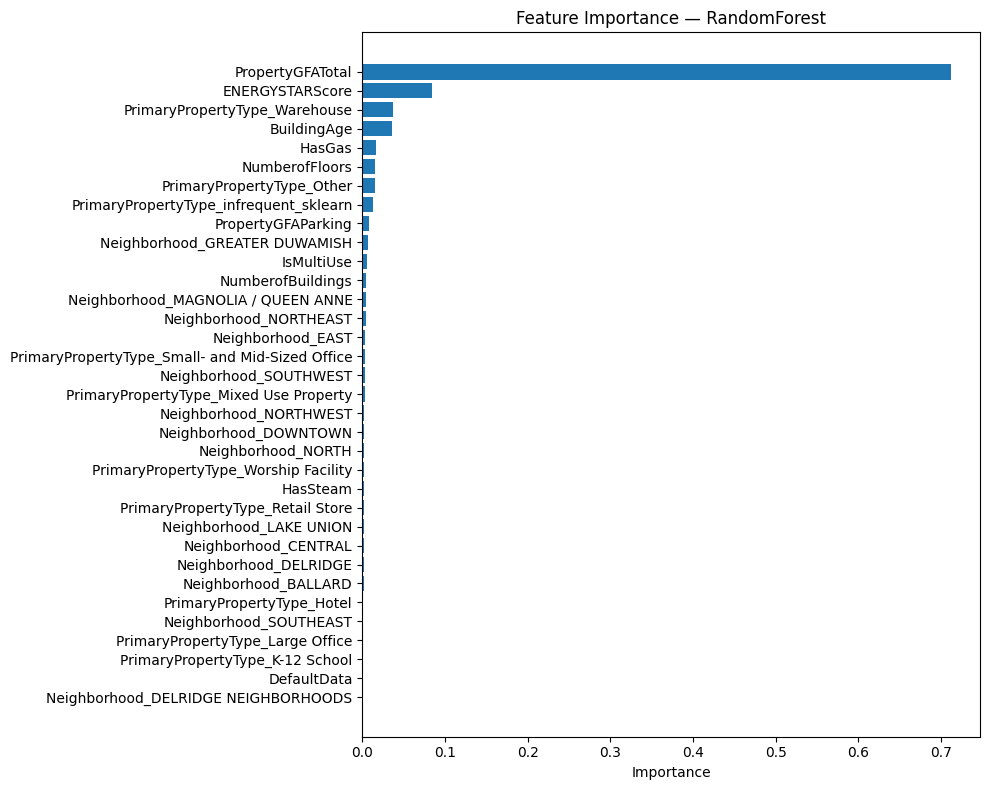

In [311]:
# 3. Visualisation — barres horizontales
plt.figure(figsize=(10, 8))
plt.barh(df_importance['feature'], df_importance['importance'])
plt.xlabel("Importance")
plt.title("Feature Importance — RandomForest")
plt.gca().invert_yaxis()  # la plus importante en haut
plt.tight_layout()
plt.show()

In [312]:
# Ratio parking / surface totale
df_check = building_consumption.copy()
df_check['ratio_parking'] = df_check['PropertyGFAParking'] / df_check['PropertyGFATotal']

# Bâtiments avec un ratio parking > 50% (parking = plus de la moitié du bâtiment)
bizarres = df_check[df_check['ratio_parking'] > 0.5][['PropertyGFATotal', 'PropertyGFAParking', 'ratio_parking', 'NumberofFloors']].sort_values('ratio_parking', ascending=False)
print(f"Bâtiments avec parking > 50% de la surface totale : {len(bizarres)}")
print(bizarres.head(10))

# Stats générales du ratio
print("\nStats ratio parking/total :")
print(df_check['ratio_parking'].describe())

Bâtiments avec parking > 50% de la surface totale : 27
      PropertyGFATotal  PropertyGFAParking  ratio_parking  NumberofFloors
1109             34636               31000       0.895023               2
163             419848              335109       0.798167               6
3267            197395              156000       0.790294               3
3233            305025              239252       0.784368               6
432              53040               41600       0.784314               1
1285            130710              100800       0.771173               6
1335             85750               65640       0.765481               2
599             361398              272900       0.755123               6
509             275982              197130       0.714286               6
830              33792               22867       0.676699               2

Stats ratio parking/total :
count    1565.000000
mean        0.063110
std         0.142090
min         0.000000
25%         0.0000

In [313]:
df_importance['importance'] = (df_importance['importance'] * 100).round(2)
df_importance.columns = ['feature', 'importance (%)']
print(df_importance.to_string(index=False))

                                        feature  importance (%)
                               PropertyGFATotal           71.16
                                ENERGYSTARScore            8.37
                  PrimaryPropertyType_Warehouse            3.66
                                    BuildingAge            3.64
                                         HasGas            1.71
                                 NumberofFloors            1.50
                      PrimaryPropertyType_Other            1.50
         PrimaryPropertyType_infrequent_sklearn            1.25
                             PropertyGFAParking            0.77
                  Neighborhood_GREATER DUWAMISH            0.66
                                     IsMultiUse            0.58
                              NumberofBuildings            0.47
             Neighborhood_MAGNOLIA / QUEEN ANNE            0.41
                         Neighborhood_NORTHEAST            0.39
                              Neighborho